## Get gamma / simple probit model

gamma does not change much with/without stake size effect (model-2 with n1 param)
not sure to take np.exp() or softplus from pos

In [4]:
from bauer.utils.data import load_garcia2022
from bauer.models import MagnitudeComparisonModel
import numpy as np
import pandas as pd
import seaborn as sns
from bauer.utils.plotting import plot_ppc
import os.path as op

target_folder ='/Users/mrenke/data/ds-miguel/derivatives/phenotype'

df = load_garcia2022()
df['log(n2/n1)'] = np.log(df['n2']/df['n1'])
df['x'] = df['log(n2/n1)']

df['chose_n2'] = df['choice'] 
# df[['choice','n1','n2','log(n1/n2)']]

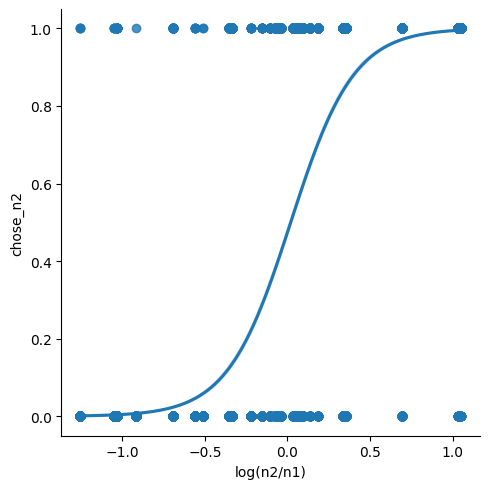

In [55]:
import seaborn as sns

sns.lmplot(data=df, x='log(n2/n1)', y='chose_n2', logistic=True)

In [5]:
import bambi 
model_label = 1
model = bambi.Model('chose_n2 ~ x + (x|subject)', link='probit', family='bernoulli', data=df.reset_index())


In [ ]:
model_label = 2
model = bambi.Model('chose_n2 ~ x + x*n1 + (x*n1|subject)', link='probit', family='bernoulli', data=df.reset_index())

In [ ]:
# fit and save trace
# fiting does not work in VS notbeook, but works in terminal

traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)
import arviz as az
az.to_netcdf(traces, op.join(target_folder, f'probit_model-{model_label}_trace.netcdf'))


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>],
       [<Axes: title={'center': '1|subject_sigma'}>,
        <Axes: title={'center': '1|subject_sigma'}>],
       [<Axes: title={'center': 'x|subject_sigma'}>,
        <Axes: title={'center': 'x|subject_sigma'}>],
       [<Axes: title={'center': '1|subject'}>,
        <Axes: title={'center': '1|subject'}>],
       [<Axes: title={'center': 'x|subject'}>,
        <Axes: title={'center': 'x|subject'}>]], dtype=object)

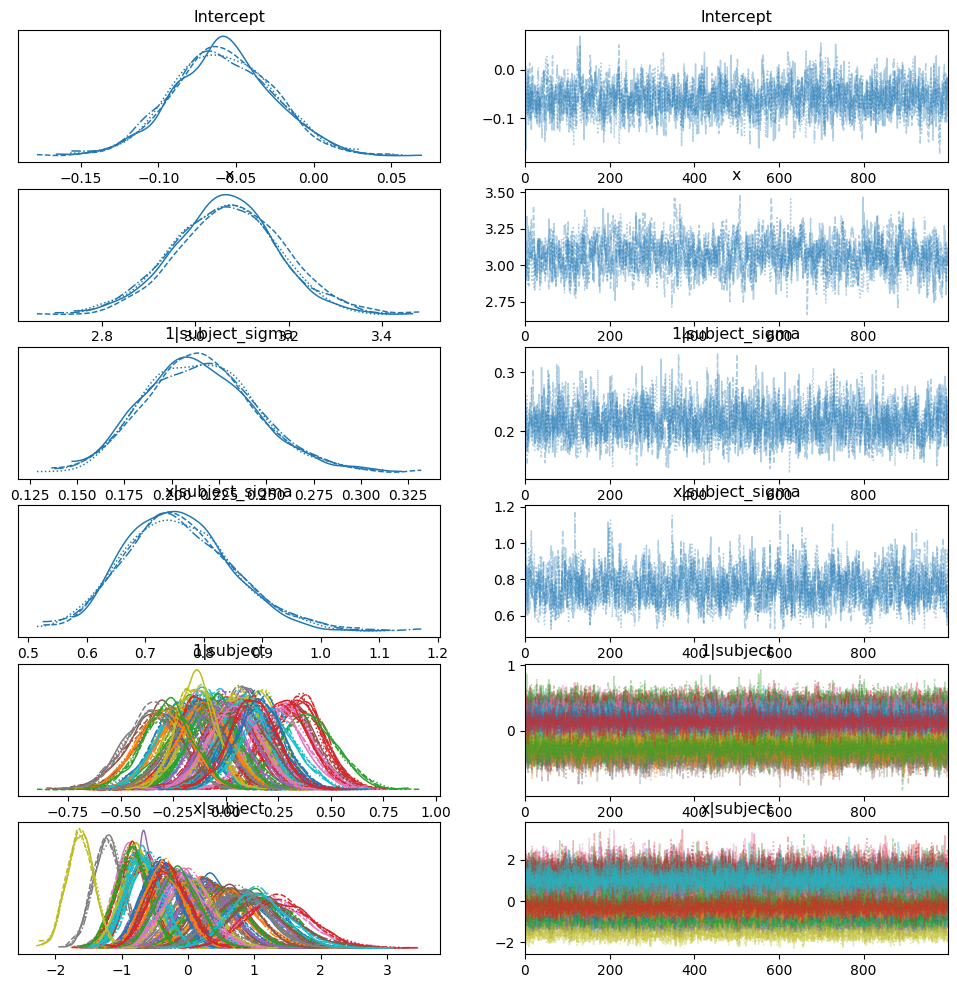

In [6]:
# load in trace (can be done in VS notebook)
import arviz as az
model_label = 1
model = bambi.Model('chose_n2 ~ x + (x|subject)', link='probit', family='bernoulli', data=df.reset_index())

idata = az.from_netcdf(op.join(target_folder, f'probit_model-{model_label}_trace.netcdf'))
az.plot_trace(idata)

In [8]:
df_gammas = idata.posterior[['x','x|subject']].to_dataframe()
df_gammas['gamma'] = df_gammas['x'] + df_gammas['x|subject']


In [9]:
df_gammas = idata.posterior[['x','x|subject']].to_dataframe()
df_gammas['gamma'] = df_gammas['x'] + df_gammas['x|subject']

df_gammas = df_gammas['gamma'].groupby('subject__factor_dim').mean()

df_gammas.index = df_gammas.index.astype(int)
df_gammas.index.name ='subject'
df_gammas.sort_index(inplace=True)

df_gammas.head()

subject
1    3.427022
2    3.278631
3    2.715850
4    2.335807
5    2.433182
Name: gamma, dtype: float64

In [17]:
df_gammas.to_csv(op.join(target_folder, f'probit_model-{model_label}_gammas.csv'))

<Axes: >

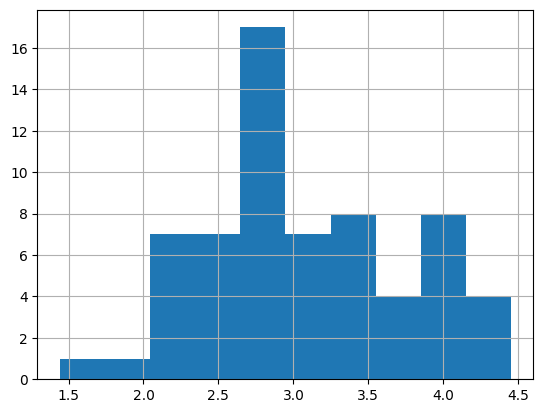

In [10]:
df_gammas.hist()

In [11]:
##
import scipy.stats as ss

def invprobit(x):
    return ss.norm.ppf(x)

def extract_rnp_precision(trace, model, data):

    data = data.reset_index()
    reg_list = [data.reset_index()['subject'].unique(),[0, 1], data['n1'].unique()] #, data['group'].unique()]
    names=['subject', 'x', 'n1'] #,'group']
    
    include_group_specific = True 

    fake_data = pd.MultiIndex.from_product(reg_list,names=names).to_frame().reset_index(drop=True)

    pred = model.predict(trace, 'mean', fake_data, inplace=False, include_group_specific=include_group_specific)['posterior']['chose_n2_mean']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred
    pred0 = pred.xs(0, 0, 'x')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

    return intercept, gamma

In [12]:
intercept, gamma= extract_rnp_precision(idata, model,df, group_level = False) # ,group=False for subs


In [13]:
gamma = gamma.stack([1, 2])
gamma.columns = ['gamma']

In [14]:
gamma

gamma
subject n1 chain draw          
1       7  0     0     3.080657
                 1     2.860290
                 2     3.639793
                 3     3.060855
                 4     3.734256
...                         ...
64      14 3     995   2.960733
                 996   2.885389
                 997   2.661641
                 998   2.757953
                 999   3.028553

[1536000 rows x 1 columns]

array([[<Axes: title={'center': 'gamma'}>]], dtype=object)

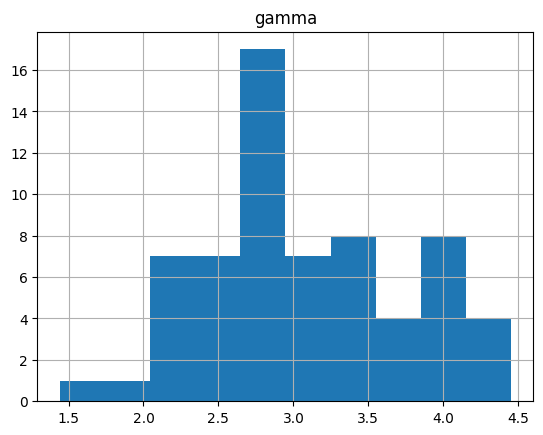

In [15]:

gamma.groupby('subject').mean().hist()